In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [2]:
# -- Data ----------------------------------------------------

CONTROL_POINTS = np.array([
    [1, 1],   # P0
    [3, 3],   # P1
    [5, 1],   # P2
])

U_HIGHLIGHT = [0.00, 0.25, 0.50, 0.75, 1.00]

In [3]:
# -- Bezier Computation --------------------------------------

class BezierQuadratic:
    """Quadratic Bezier curve from three control points."""

    def __init__(self, points: np.ndarray):
        self.p0 = points[0]
        self.p1 = points[1]
        self.p2 = points[2]

    def _basis(self, u: float) -> tuple:
        """Return Bernstein basis values at u."""
        b0 = (1 - u) ** 2
        b1 = 2 * u * (1 - u)
        b2 = u ** 2
        return b0, b1, b2

    def point(self, u: float) -> np.ndarray:
        """Return curve point at parameter u."""
        b0, b1, b2 = self._basis(u)
        return (
            b0 * self.p0
            + b1 * self.p1
            + b2 * self.p2
        )

    def curve(self, n: int = 200) -> np.ndarray:
        """Return array of curve points."""
        u_vals = np.linspace(0, 1, n)
        return np.array([self.point(u) for u in u_vals])

    def highlight_points(
        self, u_list: list
    ) -> np.ndarray:
        """Return curve points for given u values."""
        return np.array([
            self.point(u) for u in u_list
        ])

In [4]:
# -- Plot ----------------------------------------------------

class BezierPlot:
    """2D plot for a quadratic Bezier curve."""

    COLOR_CURVE   = '#1565C0'
    COLOR_POLYGON = '#E53935'
    COLOR_CTRL    = '#E53935'
    COLOR_POINT   = '#1B5E20'
    COLOR_LABEL   = '#4A148C'

    def __init__(
        self,
        bezier: BezierQuadratic,
        u_highlight: list
    ):
        self.bezier      = bezier
        self.u_highlight = u_highlight
        self.fig, self.ax = self._init_figure()

    def _init_figure(self):
        """Initialize figure with seaborn style."""
        sns.set_theme(style='whitegrid')
        fig, ax = plt.subplots(figsize=(8, 6))
        return fig, ax

    # -- Drawing helpers -------------------------------------

    def _draw_curve(self):
        """Draw the smooth Bezier curve."""
        pts = self.bezier.curve()
        self.ax.plot(
            pts[:, 0], pts[:, 1],
            color=self.COLOR_CURVE,
            linewidth=2.5,
            label='Bezier Curve',
            zorder=3
        )

    def _draw_control_polygon(self):
        """Draw dashed polygon connecting control points."""
        cp = np.array([
            self.bezier.p0,
            self.bezier.p1,
            self.bezier.p2
        ])
        self.ax.plot(
            cp[:, 0], cp[:, 1],
            color=self.COLOR_POLYGON,
            linestyle='--',
            linewidth=1.5,
            marker='o',
            markersize=8,
            label='Control Polygon',
            zorder=4
        )

    def _label_control_points(self):
        """Add P0, P1, P2 labels near control points."""
        offsets = [(-0.25, -0.20), (0.08, 0.08), (0.08, -0.20)]
        names   = [r'$P_0$(1,1)', r'$P_1$(3,3)', r'$P_2$(5,1)']
        points  = [
            self.bezier.p0,
            self.bezier.p1,
            self.bezier.p2
        ]
        for pt, name, (dx, dy) in zip(points, names, offsets):
            self.ax.annotate(
                name,
                xy=(pt[0], pt[1]),
                xytext=(pt[0] + dx, pt[1] + dy),
                fontsize=9,
                color=self.COLOR_CTRL,
                fontweight='bold'
            )

    def _draw_highlight_points(self):
        """Draw curve points at specified u values."""
        pts = self.bezier.highlight_points(self.u_highlight)
        self.ax.scatter(
            pts[:, 0], pts[:, 1],
            color=self.COLOR_POINT,
            s=70, zorder=5,
            label='Points at u'
        )

    # Per-u annotation offsets to avoid overlaps
    U_OFFSETS = {
        0.00: ( 0.08, -0.22),
        0.25: ( 0.08,  0.08),
        0.50: ( 0.08,  0.08),
        0.75: ( 0.08,  0.08),
        1.00: (-0.55, -0.22),
    }

    def _label_highlight_points(self):
        """Annotate each highlighted point with u, x, y."""
        for u in self.u_highlight:
            pt     = self.bezier.point(u)
            x, y   = pt[0], pt[1]
            dx, dy = self.U_OFFSETS.get(u, (0.08, 0.08))
            text   = f'u={u:.2f}\n({x:.2f}, {y:.2f})'
            self.ax.annotate(
                text,
                xy=(x, y),
                xytext=(x + dx, y + dy),
                fontsize=7.5,
                color=self.COLOR_LABEL,
                bbox=dict(
                    boxstyle='round,pad=0.2',
                    fc='white',
                    alpha=0.6,
                    ec='none'
                )
            )

    # -- Decoration ------------------------------------------

    def _add_equations(self):
        """Show parametric equations as figure text."""
        eq_x = r'$x(u) = 1 + 4u$'
        eq_y = r'$y(u) = -4u^2 + 4u + 1$'
        self.ax.text(
            0.02, 0.80,
            eq_x + '\n' + eq_y,
            transform=self.ax.transAxes,
            fontsize=9,
            verticalalignment='top',
            bbox=dict(
                boxstyle='round,pad=0.4',
                facecolor='lightyellow',
                alpha=0.8
            )
        )

    def _set_decorations(self):
        """Set title, labels, legend, and grid."""
        self.ax.set_title(
            'Bezier Curve: Quadratic (3 Control Points)',
            fontsize=13,
            fontweight='bold',
            pad=14
        )
        self.ax.set_xlabel('x', fontsize=11)
        self.ax.set_ylabel('y', fontsize=11)
        self.ax.legend(fontsize=9, loc='upper left')
        self.ax.set_xlim(0.5, 6.0)
        self.ax.set_ylim(0.5, 3.5)
        self.ax.set_aspect('equal')

    # -- Main ------------------------------------------------

    def draw(self):
        """Compose all plot elements."""
        self._draw_curve()
        self._draw_control_polygon()
        self._label_control_points()
        self._draw_highlight_points()
        self._label_highlight_points()
        self._add_equations()
        self._set_decorations()

    def save(self, filename: str):
        """Save figure to file (relative path)."""
        self.fig.tight_layout()
        self.fig.savefig(filename, dpi=150)
        print(f'Saved: {filename}')

    def show(self):
        """Display the figure."""
        self.fig.tight_layout()
        plt.show()

In [18]:
# -- Entry Point ---------------------------------------------

def main() -> int:
    bezier = BezierQuadratic(CONTROL_POINTS)
    plot   = BezierPlot(bezier, U_HIGHLIGHT)
    plot.draw()
    plot.save('11-bezier_quadratic.png')
    plot.show()
    return 0

Saved: 11-bezier_quadratic.png


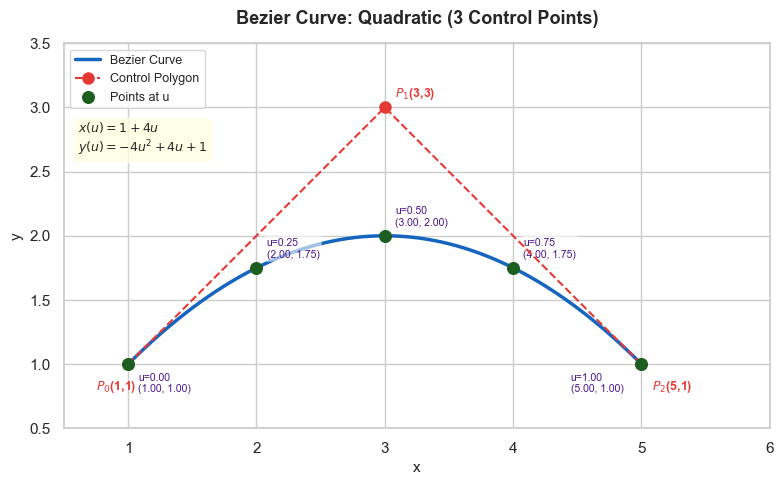

0

In [19]:
main()